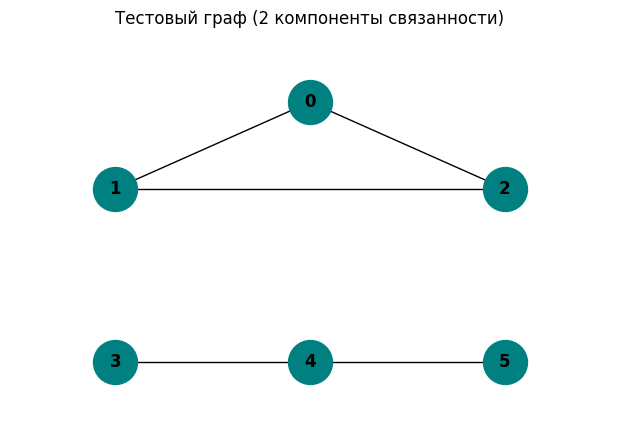

Матрица смежности:
[[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 1 0 1]
 [0 0 0 0 1 0]]


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Создаем матрицу смежности для графа из 6 вершин
# Компонента 1 (треугольник): 0-1, 1-2, 2-0
# Компонента 2 (линия): 3-4, 4-5
adj_matrix = np.array([
    [0, 1, 1, 0, 0, 0],
    [1, 0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 1, 0]
])

# 2. Создаем объект графа из матрицы
G = nx.from_numpy_array(adj_matrix)

# 3. Визуализация
# Задаем координаты вручную для красоты (x, y)
fixed_pos = {
    0: (0, 1), 1: (-0.5, 0.5), 2: (0.5, 0.5),  # Треугольник сверху
    3: (-0.5, -0.5), 4: (0, -0.5), 5: (0.5, -0.5) # Линия снизу
}

plt.figure(figsize=(6, 4))
nx.draw(G, fixed_pos, with_labels=True, 
        node_color='teal', 
        node_size=1000, 
        font_weight='bold', 
        edge_color='black')

plt.title("Тестовый граф (2 компоненты связанности)")
plt.margins(0.2) # Добавляем отступы, чтобы узлы не прижимались к краям
plt.show()

# Вывод матрицы для проверки
print("Матрица смежности:")
print(adj_matrix)

In [3]:
def find_components(matrix):
    """
    Листинг программы поиска компонент связанности графа.
    
    Переменные:
    n - количество вершин в графе (размерность матрицы смежности)
    visited - список флагов посещенных вершин (True/False)
    components - общий список для хранения найденных компонент
    current_comp - список вершин, входящих в текущую найденную компоненту
    queue - очередь для реализации обхода в ширину (BFS)
    u - текущая вершина, извлеченная из очереди
    neighbor - индекс вершины-соседа при проверке связей
    """
    n = len(matrix)
    visited = [False] * n
    components = []

    # Основной цикл обхода всех вершин графа
    for v in range(n):
        # Если вершина еще не была посещена в ходе предыдущих обходов
        if not visited[v]:
            current_comp = [] # Инициализация новой компоненты
            queue = [v]       # Создание очереди для BFS
            visited[v] = True # Пометка стартовой вершины как посещенной
            
            # Процесс обхода в ширину (BFS)
            while queue:
                u = queue.pop(0)       # Извлечение вершины из начала очереди
                current_comp.append(u) # Добавление вершины в текущую компоненту
                
                # Проверка всех возможных связей для текущей вершины u
                for neighbor in range(n):
                    # Если существует ребро и вершина-сосед не посещена
                    if matrix[u][neighbor] == 1 and not visited[neighbor]:
                        visited[neighbor] = True # Пометка соседа
                        queue.append(neighbor)   # Добавление соседа в очередь
            
            # Добавление полностью сформированной компоненты в общий список
            components.append(current_comp)
            
    return components

# Тестовый запуск на матрице смежности из пункта 1
result = find_components(adj_matrix)

# Вывод результатов для проверки
print(f"Количество компонент связанности: {len(result)}")
for i, comp in enumerate(result):
    print(f"Компонента №{i+1}: {sorted(comp)}")

Количество компонент связанности: 2
Компонента №1: [0, 1, 2]
Компонента №2: [3, 4, 5]


In [4]:
def generate_square_grid(M):
    """
    Подпрограмма создания графа типа 'правильная квадратная решетка'.
    
    Переменные:
    M - количество узлов по одной стороне решетки
    n - общее количество вершин (M*M)
    matrix - матрица смежности размера n x n
    v - текущая рассматриваемая вершина
    r, c - координаты вершины (строка и столбец) в сетке
    """
    n = M * M
    # Создаем пустую матрицу смежности, заполненную нулями
    matrix = np.zeros((n, n), dtype=int)
    
    for v in range(n):
        r = v // M  # вычисляем номер строки
        c = v % M   # вычисляем номер столбца
        
        # Проверка связи с правым соседом (горизонтальное ребро)
        if c < (M - 1):
            matrix[v][v + 1] = 1
            matrix[v + 1][v] = 1
            
        # Проверка связи с нижним соседом (вертикальное ребро)
        if r < (M - 1):
            matrix[v][v + M] = 1
            matrix[v + M][v] = 1
            
    return matrix

# Пример создания решетки 3x3 (9 вершин)
M_test = 3
grid_matrix = generate_square_grid(M_test)

print(f"Матрица смежности для решетки {M_test}x{M_test} создана.")
print(f"Размер матрицы: {grid_matrix.shape}")

Матрица смежности для решетки 3x3 создана.
Размер матрицы: (9, 9)


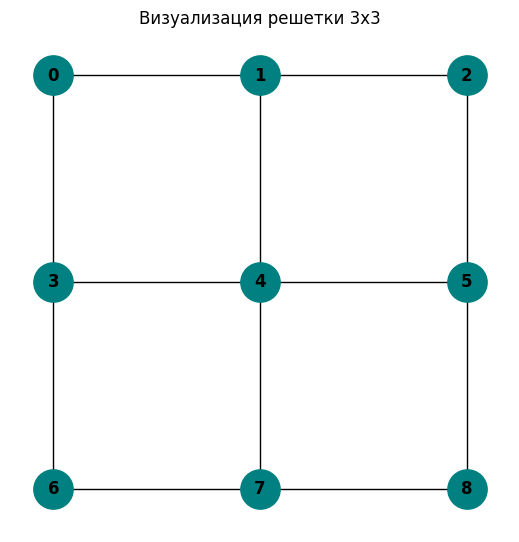

In [6]:
# Создаем граф из матрицы
G_grid = nx.from_numpy_array(grid_matrix)

# Задаем координаты вершин, чтобы они стояли ровно как в сетке
pos = {v: (v % M_test, -(v // M_test)) for v in range(M_test * M_test)}

plt.figure(figsize=(5, 5))
nx.draw(G_grid, pos, with_labels=True, node_color='teal', 
        node_size=800, font_weight='bold')
plt.title(f"Визуализация решетки {M_test}x{M_test}")
plt.show()

In [7]:
import time

# Список размеров стороны решетки M
m_values = list(range(2, 26)) 
# Списки для хранения результатов
n_values = []      # Общее количество вершин (M*M)
times = []         # Среднее время выполнения

print("Запуск эксперимента...")

for M in m_values:
    # 1. Генерируем решетку
    grid = generate_square_grid(M)
    n_values.append(M * M)
    
    # 2. Замеряем время (делаем 100 запусков для точности)
    start_time = time.perf_counter()
    for _ in range(100):
        find_components(grid)
    end_time = time.perf_counter()
    
    # Считаем среднее время одного запуска в секундах
    average_time = (end_time - start_time) / 100
    times.append(average_time)
    
    if M % 5 == 0:
        print(f"Обработана решетка {M}x{M} (N={M*M})")

Запуск эксперимента...
Обработана решетка 5x5 (N=25)
Обработана решетка 10x10 (N=100)
Обработана решетка 15x15 (N=225)
Обработана решетка 20x20 (N=400)
Обработана решетка 25x25 (N=625)


In [8]:
print(f"{'Кол-во вершин (N)':<20} | {'Среднее время (сек)':<20}")
print("-" * 45)

# Выведем каждое второе или третье значение, чтобы таблица не была слишком длинной
for n, t in zip(n_values, times):
    if (n_values.index(n) % 3 == 0): # берем каждое третье значение для компактности
        print(f"{n:<20} | {t:<20.8f}")

Кол-во вершин (N)    | Среднее время (сек) 
---------------------------------------------
4                    | 0.00000609          
25                   | 0.00015443          
64                   | 0.00117199          
121                  | 0.00465115          
196                  | 0.01078407          
289                  | 0.02418151          
400                  | 0.04741422          
529                  | 0.08225330          


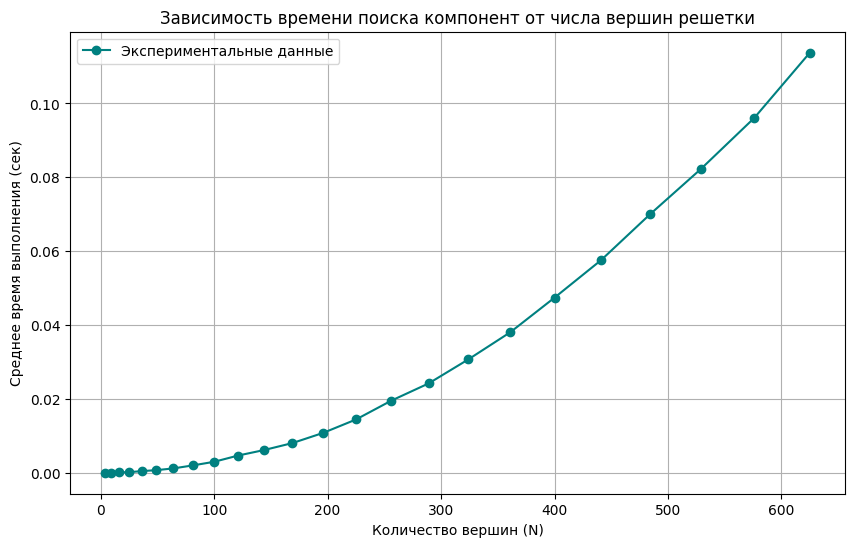

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(n_values, times, marker='o', linestyle='-', color='teal', label='Экспериментальные данные')
plt.xlabel('Количество вершин (N)')
plt.ylabel('Среднее время выполнения (сек)')
plt.title('Зависимость времени поиска компонент от числа вершин решетки')
plt.grid(True)
plt.legend()
plt.show()